In [1]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import csr_matrix
import scanpy as sc
from itertools import chain
import itertools
import networkx as nx
import scglue
import seaborn as sns
from matplotlib import rcParams
import sys
import os
print(ad.__version__)
utils_path = "C:/Users/Acer/Desktop/ST&SM Integrator"
if utils_path not in sys.path:
    sys.path.append(utils_path)
import MSTI_Guidancegraph as MG
import MSTI_preprocess as MP
import warnings
warnings.filterwarnings('ignore')

C:\Users\Acer\.conda\envs\clean\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Acer\.conda\envs\clean\Lib\site-packages\ignite\handlers\checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


0.9.2


## Alignment

In [2]:
file_path = 'C:/Users/Acer/Desktop/ST&SM Integrator/data/MT/59430-neg.txt'
meta = MP.process_mt_data(file_path)
meta_bc = meta

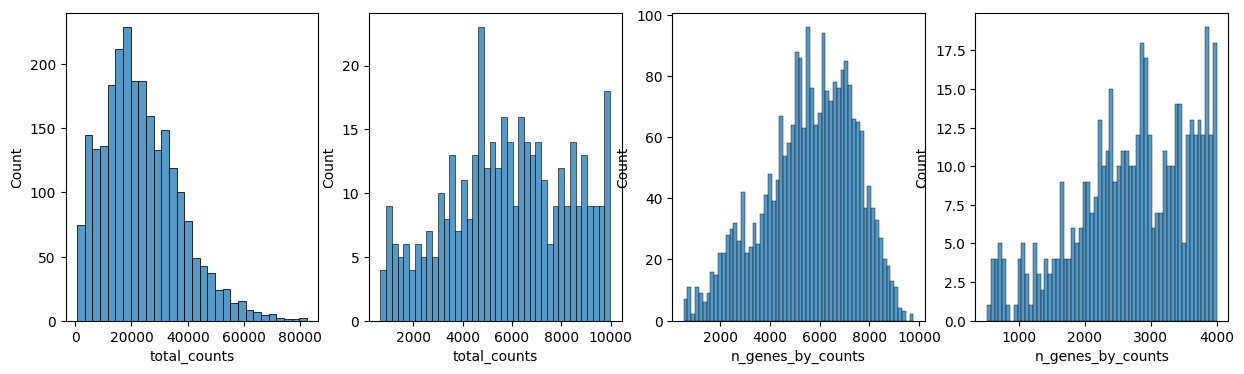

In [3]:
visium_path = 'C:/Users/Acer/Desktop/ST&SM Integrator/data/ST/NO.77137/outs'
rna = MP.process_st_data(visium_path)
rna_bc = rna

In [4]:
kegg_rna = pd.read_csv('C:/Users/Acer/Desktop/ST&SM Integrator/data/KEGG_Dataset/hsa_kegg_gene.csv')
kegg_reaction = pd.read_csv('C:/Users/Acer/Desktop/ST&SM Integrator/data/KEGG_Dataset/keggAllreaction.csv')
sample_mt = pd.read_excel('C:/Users/Acer/Desktop/ST&SM Integrator/data/KEGG_Dataset/ALL_sample_data_neg.xlsx')

In [5]:
guidance = MG.MSTI_kegg_Guidancegraph(rna, meta, kegg_reaction,sample_mt, kegg_rna)

Creating KEGG reaction graph...
KEGG reaction graph completed!
Graph completed!


In [6]:
scglue.graph.check_graph(guidance, [rna, meta])

[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] check_graph: All checks passed!


In [7]:
scglue.models.configure_dataset(
    rna, "NB", use_layer="counts",use_highly_variable=True,
    use_rep="X_pca"
)
scglue.models.configure_dataset(
    meta, "NB", use_layer="counts",use_highly_variable=True,
     use_rep="X_pca"
)
guidance_hvf = guidance.subgraph(chain(
    rna.var.query("highly_variable").index,
    meta.var.query("highly_variable").index
)).copy()

In [8]:
glue = scglue.models.fit_SCGLUE(
    {"rna": rna, "meta": meta}, guidance_hvf,
    fit_kws={"directory": "glue"}
)

[INFO] fit_SCGLUE: Pretraining SCGLUE model...
[INFO] autodevice: Using GPU 0 as computation device.
[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] SCGLUEModel: Setting `graph_batch_size` = 1194
[INFO] SCGLUEModel: Setting `max_epochs` = 48
[INFO] SCGLUEModel: Setting `patience` = 4
[INFO] SCGLUEModel: Setting `reduce_lr_patience` = 2
[INFO] SCGLUETrainer: Using training directory: "glue\pretrain"
[INFO] SCGLUETrainer: [Epoch 10] train={'g_nll': 0.045, 'g_kl': 0.055, 'g_elbo': 0.099, 'x_rna_nll': 0.486, 'x_rna_kl': 0.006, 'x_rna_elbo': 0.491, 'x_meta_nll': 1.084, 'x_meta_kl': 0.036, 'x_meta_elbo': 1.12, 'dsc_loss': 0.684, 'vae_loss': 1.616, 'gen_loss': 1.581}, val={'g_nll': 0.043, 'g_kl': 0.055, 'g_elbo': 0.098, 'x_rna_nll': 0.499, 'x_rna_kl': 0.006, 'x_rna_elbo': 0.505, 'x_meta_nll': 1.08, 'x_meta_kl': 0.036, 'x_meta_elbo': 1.115, 'dsc_los

2025-03-04 13:11:32,777 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "40"...
[INFO] EarlyStopping: Restoring checkpoint "40"...
[INFO] fit_SCGLUE: Estimating balancing weight...
[INFO] estimate_balancing_weight: Clustering cells...
[INFO] estimate_balancing_weight: Matching clusters...
[INFO] estimate_balancing_weight: Matching array shape = (14, 24)...
[INFO] estimate_balancing_weight: Estimating balancing weight...
[INFO] fit_SCGLUE: Fine-tuning SCGLUE model...
[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] SCGLUEModel: Setting `graph_batch_size` = 1194
[INFO] SCGLUEModel: Setting `align_burnin` = 8
[INFO] SCGLUEModel: Setting `max_epochs` = 48
[INFO] SCGLUEModel: Setting `patience` = 4
[INFO] SCGLUEModel: Setting `reduce_lr_patience` = 2
[INFO] SCGLUETrainer: Using training directory: "glue\fine-tune"
[INFO] SCGLUETrainer: [Epoch 10] train={'g_nll': 0.046, 'g_kl'

2025-03-04 13:24:16,131 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "20"...
[INFO] EarlyStopping: Restoring checkpoint "20"...


In [9]:
rna.obsm["X_glue"] = glue.encode_data("rna", rna)
meta.obsm["X_glue"] = glue.encode_data("meta", meta)
rna.obs['domain'] = 'rna'
meta.obs['domain'] = 'meta'
combined = ad.concat([rna, meta])

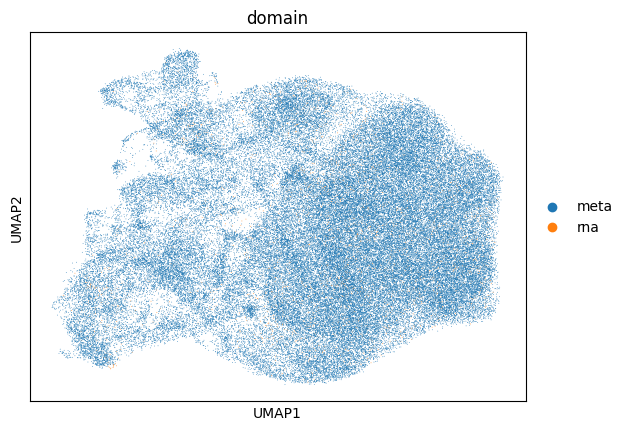

In [10]:
sc.pp.neighbors(combined, use_rep="X_glue", metric="cosine")
sc.tl.umap(combined)
sc.pl.umap(combined, color='domain', wspace=0.65)

In [11]:
rna_index = rna_bc
rna = combined[combined.obs['domain'] == 'rna']
meta = combined[combined.obs['domain'] == 'meta']
df_rna = pd.DataFrame(rna.obsm['X_glue'])
df_meta = pd.DataFrame(meta.obsm['X_glue'])
df_rna_adata = ad.AnnData(X=df_rna)
df_meta_adata = ad.AnnData(X=df_meta)
df_rna_adata.obs = pd.DataFrame(index=rna.obs.index)
df_meta_adata.obs = pd.DataFrame(index=meta.obs.index)
df_meta_adata.obs['x'] = df_meta_adata.obs.index.str.split('x').str[0]
df_meta_adata.obs['y'] = df_meta_adata.obs.index.str.split('x').str[1]
df_meta_adata.obs['array_row'] = df_meta_adata.obs['x']
df_meta_adata.obs['array_col'] = df_meta_adata.obs['y']
df_meta_adata.obs['x_spa'] = df_meta_adata.obs['x'].astype(float) * 117.6471
df_meta_adata.obs['y_spa'] = df_meta_adata.obs['y'].astype(float) * 117.6471
df_rna_adata.obs['domain'] = 'rna'
df_meta_adata.obs['domain'] = 'meta'
combined = ad.concat([df_rna_adata, df_meta_adata])

In [12]:
combined.var_names_make_unique()
combined.layers["counts"] = combined.X.copy()
sc.pp.neighbors(combined)
sc.tl.umap(combined)

In [13]:
sc.tl.louvain(
    combined,
    resolution=0.1,
    random_state=0,

    key_added='louvain',
    directed=False,
)

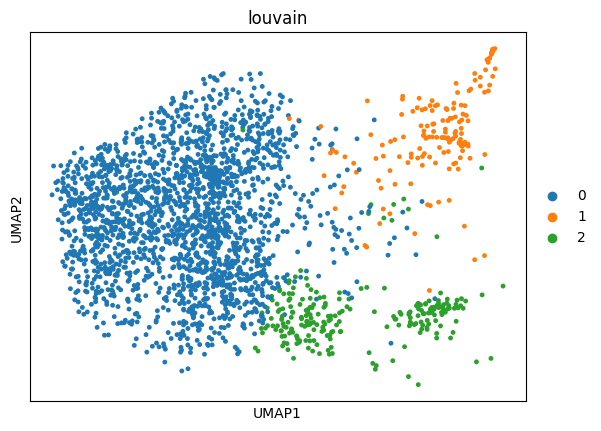

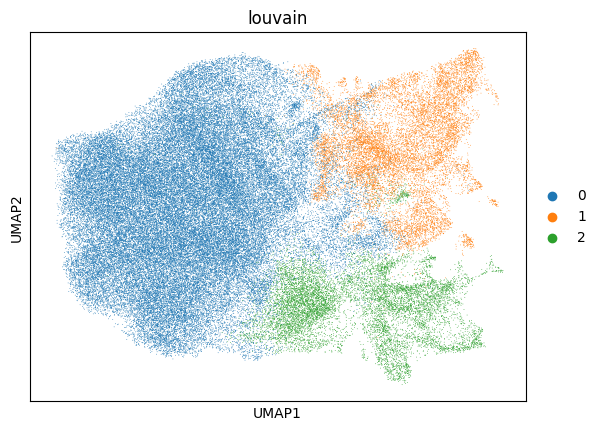

In [14]:
domain_rna = combined[combined.obs['domain'] == 'rna']
sc.pl.umap(domain_rna, color='louvain')
domain_meta = combined[combined.obs['domain'] == 'meta']
sc.pl.umap(domain_meta, color='louvain')

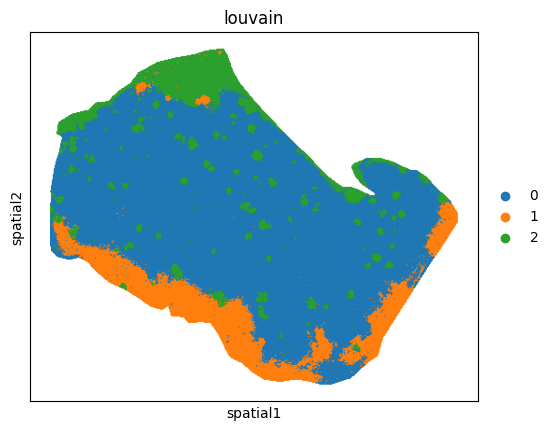

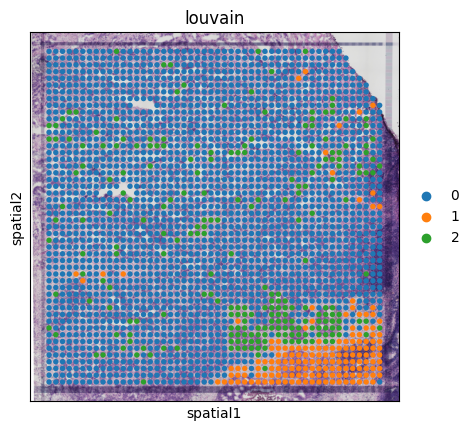

In [15]:
meta_spa = meta_bc
rna_spa = rna_bc
meta_spa.obs['louvain'] = domain_meta.obs['louvain']
sc.pl.spatial(meta_spa, color="louvain", spot_size=2)
rna_spa.obs['louvain'] = domain_rna.obs['louvain']
sc.pl.spatial(rna_spa, color="louvain",size=0.8)

In [16]:
combined.write_h5ad('IBC_3.h5ad')
#glue.save("IBC_3.dill")